# Chapter 1 — Optimal transport on two 2D Gaussians (companion notebook)

This notebook is the executable companion to `chapter.md`. It imports the production solvers from `src/ot_steering/ot/` and the shared demo from `phases/phase_01_ot_foundations/experiments/demo.py`, so the code you see here is the same code that ships in the rest of the project — no parallel re-implementation.

Run order: top to bottom. Total runtime: a few seconds.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Make the phase's experiments/ module importable.
experiments_dir = Path.cwd() / "experiments"
if str(experiments_dir) not in sys.path:
    sys.path.insert(0, str(experiments_dir))

from demo import run_demo  # noqa: E402
from make_figures import (  # noqa: E402
    _fig_point_clouds,
    _fig_ot_plan_lines,
    _fig_plan_heatmaps,
    _fig_displacement_interpolation,
)

print("loaded demo from", experiments_dir)

loaded demo from /home/adimunot21/projects/ot-concept-transport/phases/phase_01_ot_foundations/experiments


## 1. Two clouds, equal mass, different locations

The setup. Two 60-point clouds, both with uniform weights $a_i = 1/n$ and $b_j = 1/m$. We treat each point as a unit of mass and ask: what is the cheapest assignment of source mass to target mass under squared-Euclidean cost?

source shape: (60, 2)
target shape: (60, 2)
cost matrix shape: (60, 60)


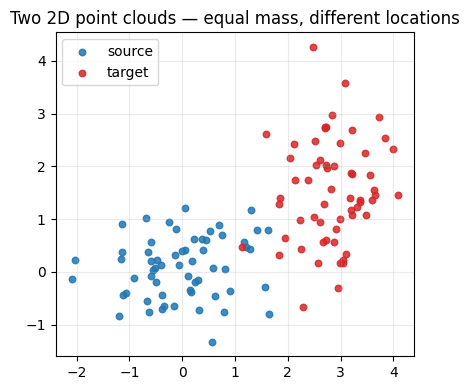

In [2]:
demo = run_demo()
print("source shape:", demo.source.shape)
print("target shape:", demo.target.shape)
print("cost matrix shape:", demo.cost.shape)
fig = _fig_point_clouds(demo)
plt.show()

## 2. The exact OT plan

Each line connects a source point to a target point; line width is proportional to how much mass is sent along that edge. The plan is sparse — most pairs carry zero mass. That sparsity is a property of the unregularised Kantorovich solution.

max plan entry: 0.016666666666666666
# of plan entries > 1e-3: 60
total cost (EMD): 10.41109205458349


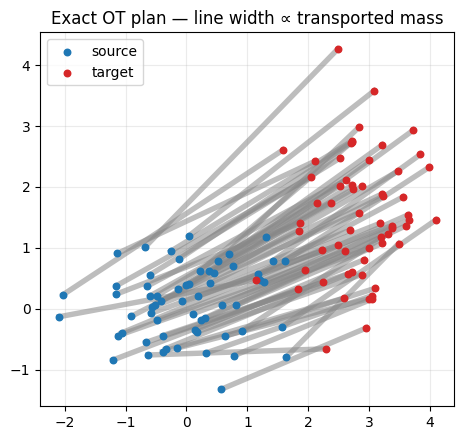

In [3]:
print("max plan entry:", demo.plan_emd.max())
print("# of plan entries > 1e-3:", int((demo.plan_emd > 1e-3).sum()))
print("total cost (EMD):", float((demo.plan_emd * demo.cost).sum()))
fig = _fig_ot_plan_lines(demo)
plt.show()

## 3. Entropic regularisation as a knob

Sinkhorn solves a *regularised* OT problem: it adds $-\varepsilon \, H(P)$ to the objective, where $H$ is Shannon entropy. As $\varepsilon \to 0$, the plan becomes sparser and approaches the EMD solution; as $\varepsilon$ grows, the plan blurs toward the rank-one product of marginals (every source point sends a little mass to every target point).

The figure shows the same problem solved at three regularisation strengths, side-by-side with the EMD reference.

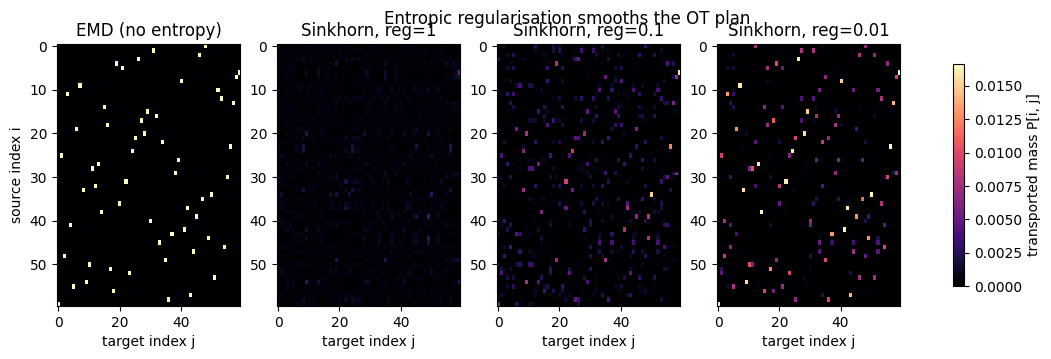

In [4]:
fig = _fig_plan_heatmaps(demo)
plt.show()

## 4. Displacement interpolation

The OT plan does more than match points: it defines a geodesic in distribution space. We can interpolate between source and target by computing the barycentric image of the source through the plan, then moving each source point a fraction $t \in [0, 1]$ of the way to its image. This is *displacement interpolation* (McCann's interpolant), and it is the OT-native answer to "halfway between these two distributions."

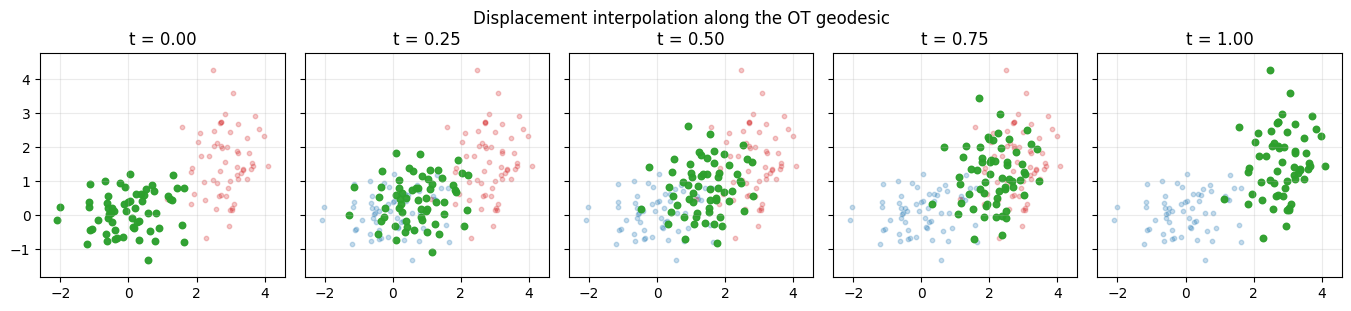

In [5]:
fig = _fig_displacement_interpolation(demo)
plt.show()

## What we just learned

- The exact OT plan between two equal-mass discrete clouds is sparse: most pairs carry no mass.
- Sinkhorn's entropic regularisation smoothly interpolates between EMD (sparse, exact) and the uninformative product-of-marginals plan (fully dense, no transport structure).
- The barycentric projection of the OT plan gives a map from source points to target locations, and that map defines a geodesic — displacement interpolation — that we will reuse in every later chapter.

Next: Chapter 2 generalises everything we did here to the case where the source and target distributions live in *incomparable* spaces. That is Gromov–Wasserstein.